Runs the full walk-forward portfolio backtest and presents the headline outputs:
equity curves, per-pair breakdown, and a metrics summary table.

In [14]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.loader import load_data
from src.pairs.selection import test_all_pairs
from src.strategy.backtest import BacktestParams, run_portfolio_backtest
from src.analysis.performance import compute_metrics, compute_metrics_with_positions

sns.set_theme(style="whitegrid")
%matplotlib inline

In [15]:
prices, _ = load_data(config_path="../config/params.yaml")
pairs = test_all_pairs(prices, pvalue_threshold=0.05, top_n=20)
print(f"{len(pairs)} pairs selected")
pairs

Dropped 2 tickers (insufficient history): {'WBA', 'DOW'}


20 pairs selected


,ticker_a,ticker_b,coint_pvalue,hedge_ratio_ols
0,MA,V,0.000011,1.872711
1,ACN,UNP,0.000308,1.805248
2,AVGO,BKNG,0.000539,0.054175
3,IBM,NVDA,0.000589,0.829063
4,AVGO,IBM,0.000659,1.328943
5,AMD,UNP,0.001074,1.137829
6,ACN,HD,0.001258,1.002010
7,ACN,LOW,0.001402,1.249416
8,MS,PM,0.002256,1.315181
9,HON,TXN,0.002319,0.755016


In [16]:
params = BacktestParams(
    entry_z=2.0,
    exit_z=0.5,
    stop_z=3.5,
    zscore_window=252,
    cost_bps=5.0,
    notional=1.0,
    formation=252,
    trading=63,
    step=21,
)

results = run_portfolio_backtest(prices, pairs, params)
portfolio   = results["portfolio"]
pair_results = results["pairs"]

port = portfolio.dropna()
print(f"{len(pair_results)} pairs backtested, {len(port)} trading days in portfolio")

20 pairs backtested, 1491 trading days in portfolio


Portfolio equity curve

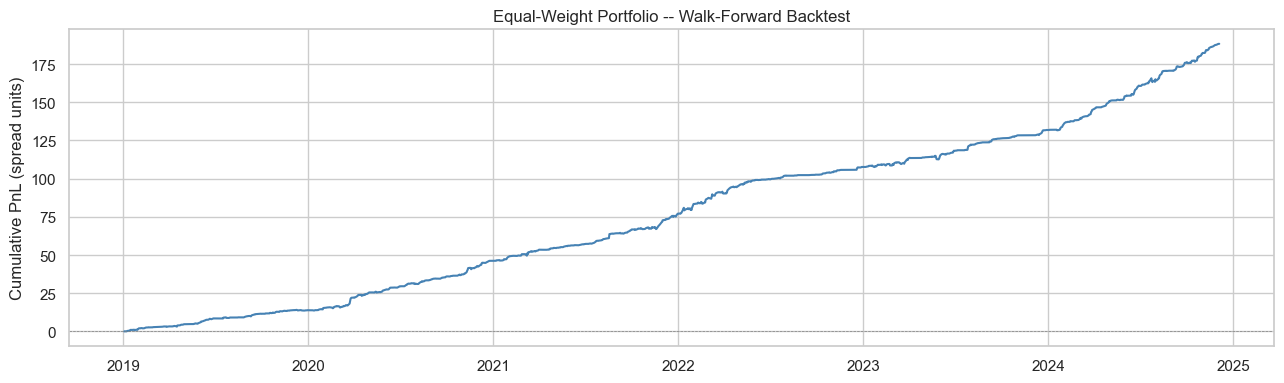

In [17]:
fig, ax = plt.subplots(figsize=(13, 4))

ax.plot(port.index, port["cumulative_pnl"], linewidth=1.5, color="steelblue")
ax.axhline(0, color="grey", linewidth=0.5, linestyle="--")
ax.set_ylabel("Cumulative PnL (spread units)")
ax.set_title("Equal-Weight Portfolio -- Walk-Forward Backtest")

plt.tight_layout()
fig.savefig("../imgs/portfolio_equity.png", dpi=150, bbox_inches="tight")
plt.show()

Per-pair equity curves

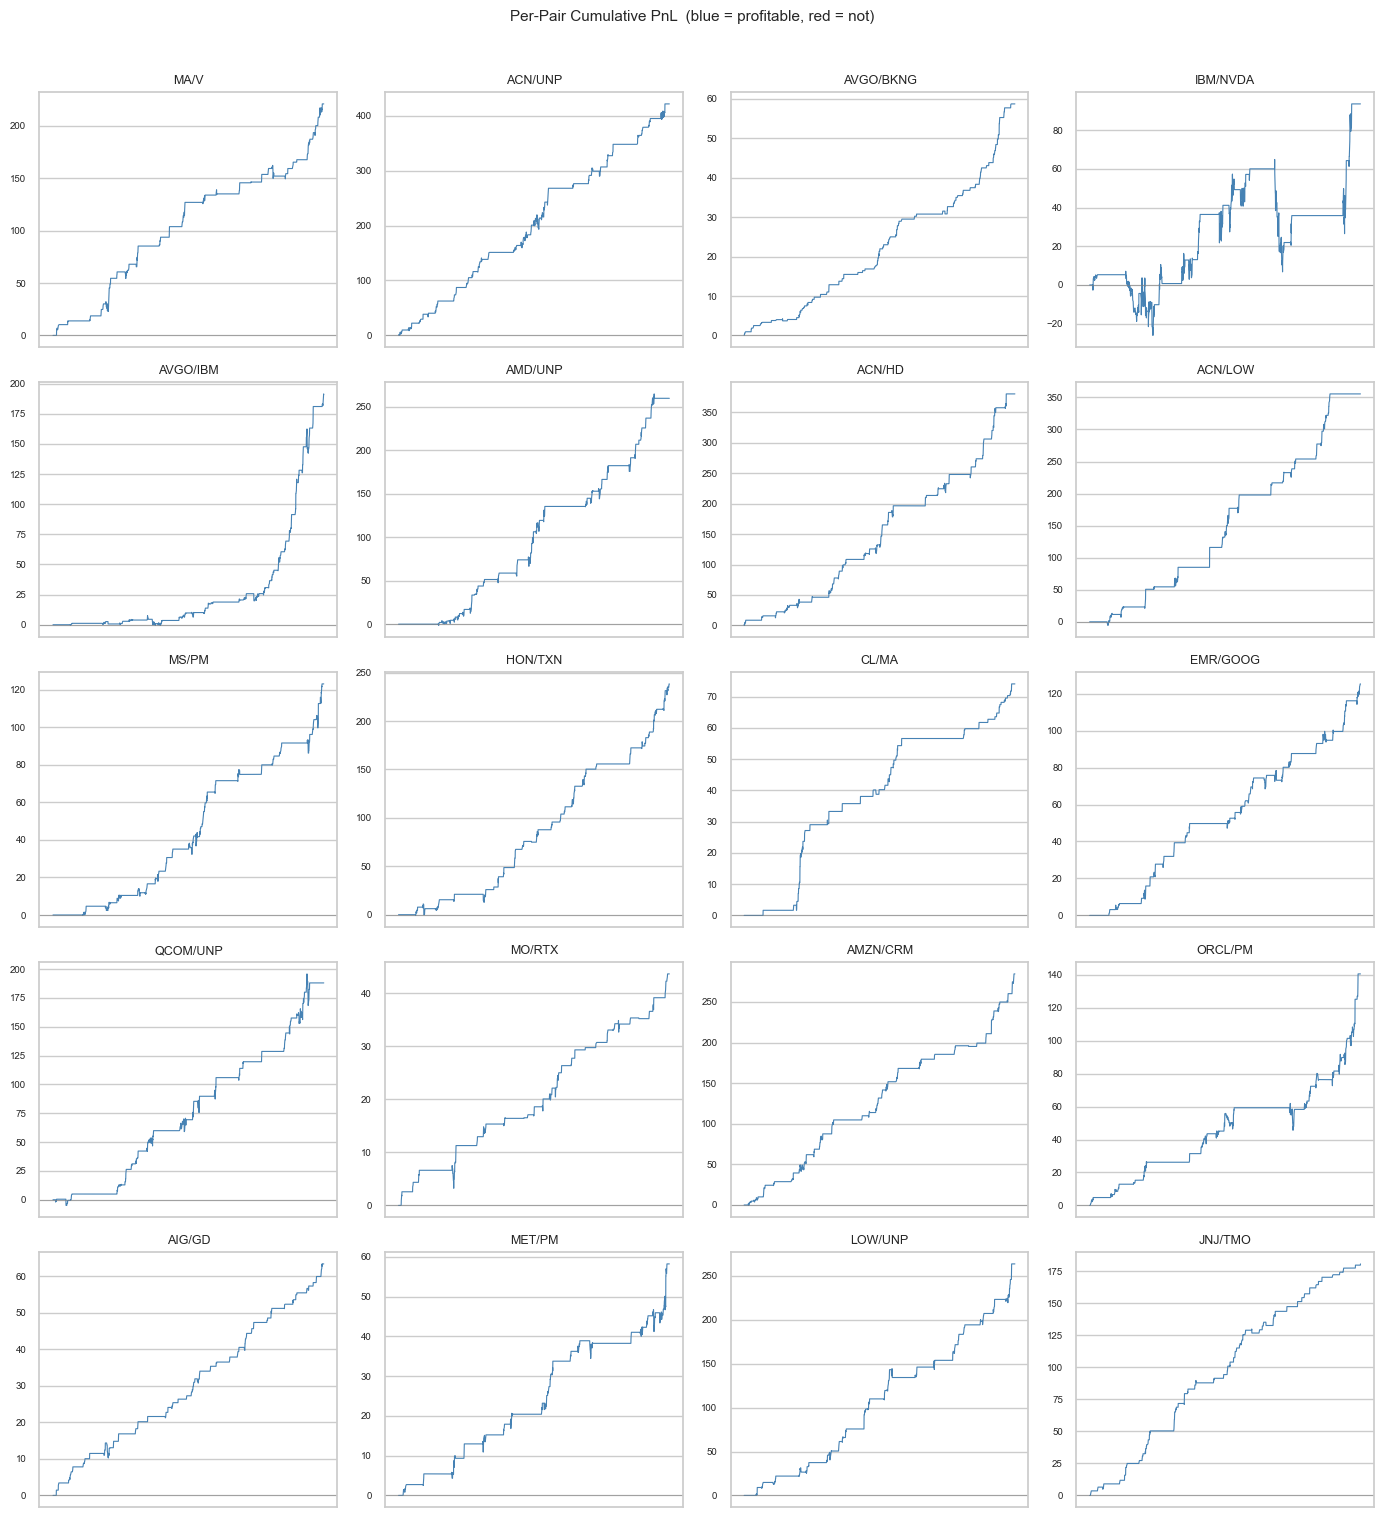

In [18]:
ncols = 4
nrows = (len(pair_results) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3 * nrows))
axes = axes.flatten()

for i, (name, df) in enumerate(pair_results.items()):
    ax = axes[i]
    cum = df["daily_pnl"].cumsum()
    final_pnl = cum.iloc[-1]
    color = "steelblue" if final_pnl >= 0 else "salmon"
    ax.plot(cum.index, cum.values, linewidth=0.8, color=color)
    ax.axhline(0, color="grey", linewidth=0.4)
    ax.set_title(name, fontsize=9)
    ax.tick_params(labelsize=7)
    ax.set_xticks([])

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Per-Pair Cumulative PnL  (blue = profitable, red = not)", fontsize=11, y=1.01)
plt.tight_layout()
fig.savefig("../imgs/per_pair_equity.png", dpi=150, bbox_inches="tight")
plt.show()

Metrics summary

In [19]:
rows = []
for name, df in pair_results.items():
    m = compute_metrics_with_positions(df["daily_pnl"], df["position"])
    m["pair"] = name
    rows.append(m)

# Portfolio row — no single position series, omit turnover
pm = compute_metrics(portfolio["daily_pnl"])
pm["pair"] = "── PORTFOLIO ──"
rows.append(pm)

summary = (
    pd.DataFrame(rows)
    .set_index("pair")[["sharpe", "annual_return", "max_drawdown", "win_rate", "turnover"]]
)
summary.columns = ["Sharpe", "Ann. Return", "Max Drawdown", "Win Rate", "Turnover"]
summary.round({"Sharpe": 2, "Ann. Return": 4, "Max Drawdown": 4, "Win Rate": 4, "Turnover": 3})

,Sharpe,Ann. Return,Max Drawdown,Win Rate,Turnover
pair,,,,,
MA/V,2.28,37.3641,-12.8781,0.5551,0.067
ACN/UNP,2.46,71.3224,-26.3703,0.6145,0.052
AVGO/BKNG,3.46,9.9274,-0.7101,0.5738,0.111
IBM/NVDA,0.46,15.8191,-58.1086,0.4741,0.042
AVGO/IBM,2.11,32.3170,-20.1378,0.5172,0.065
AMD/UNP,1.99,43.8789,-11.8594,0.5448,0.060
ACN/HD,2.66,64.2347,-15.4087,0.5451,0.052
ACN/LOW,2.25,60.0831,-12.3504,0.6041,0.042
MS/PM,2.05,20.8223,-7.0654,0.5828,0.048
